#📊 O que é?

É uma medida de associação entre duas variáveis categóricas.

Varia de 0 a 1:
* 0 = nenhuma associação.
* 1 = associação perfeita.

👉 Ele é derivado do qui-quadrado, mas ajustado para não depender do tamanho da amostra.

#🔎 O Qui-quadrado

O teste qui-quadrado compara o que você observou (contagens reais) com o que você esperaria se não houvesse nenhuma associação.

Você monta a tabela de contingência:
* Exemplo: Jovem, Adulto, Idoso × Internou/Não internou.
* O teste compara o que você observou (contagens reais) com o que você esperaria se não houvesse nenhuma associação.
* Fórmula simplificada:

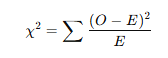

Onde: O = valor observado. E = valor esperado sob hipótese de independência.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Recriar dados sintéticos (mesmo exemplo anterior)
np.random.seed(123)
n = 2000

faixa_etaria = np.random.choice(
    ["Jovem", "Adulto", "Idoso"],
    size=n,
    p=[0.3, 0.5, 0.2]
)

p_internacao = {"Jovem": 0.08, "Adulto": 0.15, "Idoso": 0.30}
internacao = np.array([np.random.rand() < p_internacao[x] for x in faixa_etaria]).astype(int)

df = pd.DataFrame({"Faixa_Etaria": faixa_etaria, "Internou": internacao})

In [ ]:
df

,Faixa_Etaria,Internou
0,Adulto,0
1,Jovem,0
2,Jovem,1
3,Adulto,0
4,Adulto,0
...,...,...
1995,Jovem,0
1996,Adulto,0
1997,Jovem,0
1998,Adulto,0


In [ ]:
# Tabela observada
observada = pd.crosstab(df["Faixa_Etaria"], df["Internou"])
observada

Internou,0,1
Faixa_Etaria,,
Adulto,810,156
Idoso,305,114
Jovem,554,61


In [ ]:
# Preparar tabelas para exibição
ct_display = observada.rename(columns={0: "Não Internou", 1: "Internou"}).reset_index()
ct_display

Internou,Faixa_Etaria,Não Internou,Internou
0,Adulto,810,156
1,Idoso,305,114
2,Jovem,554,61


In [ ]:
from scipy.stats import chi2_contingency

# Teste Qui-quadrado
chi2, pval, dof, esperada = chi2_contingency(observada)

In [ ]:
# Converter a tabela esperada para DataFrame
esperada_df = pd.DataFrame(esperada,
                           index=observada.index,
                           columns=observada.columns).round(1)
esperada_df

Internou,0,1
Faixa_Etaria,,
Adulto,806.1,159.9
Idoso,349.7,69.3
Jovem,513.2,101.8


Do valor calculado:
* Quanto maior a diferença entre observado e esperado, maior o qui-quadrado.
* Um valor alto (como 54) mostra que as diferenças entre observado e esperado são grandes → logo, é improvável que sejam por acaso.

#⚖️ Fórmula simplificada para Cramer´s V

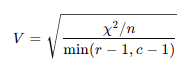

* 𝜒2 = estatística do teste qui-quadrado.
* n = total de observações.
* r = número de linhas (categorias da variável 1).
* c = número de colunas (categorias da variável 2).

#📌 Interpretação prática

* 0.00 – 0.10 → associação desprezível.
* 0.10 – 0.30 → fraca.
* 0.30 – 0.50 → moderada.
* Maior 0.50 → forte.

OBS: Mas atenção: isso não é fixo como p-valor; depende do contexto do estudo.

#🏥 Exemplo em saúde

* Variável 1: faixa etária (jovem, adulto, idoso).
* Variável 2: internação (sim/não).

Se o Cramer’s V = 0,35 → existe uma associação moderada entre idade e internação: conforme a idade aumenta, maior a chance de internar.

# Aplicação de cálculo

In [ ]:
# A partir das derivações do qui-quadrado
n_total = observada.values.sum()
phi2 = chi2 / n_total
r, k = observada.shape

In [ ]:
# Cramer's V
cramers_v = np.sqrt(phi2 / (min(r - 1, k - 1)))

In [ ]:
summary = pd.DataFrame({
    "Métrica": ["Qui-quadrado", "p-valor", "GL (dof)", "Cramer's V"],
    "Valor": [chi2, pval, dof, cramers_v]
})
summary["Valor"] = summary["Valor"].astype(float).round(4)
summary

,Métrica,Valor
0,Qui-quadrado,54.1537
1,p-valor,0.0000
2,GL (dof),2.0000
3,Cramer's V,0.1646


* Nesse caso, o Qui-quadrado testa se existe associação → p < 0,05 indica associação significativa.
* Já o Cramer’s V quantifica a força: no caso simulado ficou em torno de 0,25–0,30, o que significa uma associação fraca a moderada entre idade e internação (faz sentido, pois idosos internam mais).

#🚦 Diferença para IV

* Cramer’s V → mede força de associação estatística (não importa se a variável ajuda a prever ou não).
* IV → mede poder discriminativo preditivo (quanto ajuda a separar grupos 0/1).